# Distance Transform Explorer

Goal: find a visually pleasing monotonic mapping `d_real → d_scene` for 3D star placement.

- **Blue** — stars with Gaia parallax (true distances)
- **Orange** — all others (no parallax / no Gaia match) → placed at a configurable background distance

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning

from detect import SEPDetector
from catalog import query_gaia, crossmatch

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## 1. Load data
Loads a cached `matches.parquet` if available, otherwise runs detection + Gaia crossmatch and saves it.

In [2]:
CACHE_PATH  = "matches.parquet"
IMAGE_PATH  = "test_solved_star.fits"
FIELD_RA    = 13.2153
FIELD_DEC   = 56.6571
FIELD_RADIUS = 0.75     # degrees
PIXSCALE    = 2.697     # arcsec / pixel

import os
if os.path.exists(CACHE_PATH):
    matches = pd.read_parquet(CACHE_PATH)
    print(f"Loaded {len(matches)} sources from cache.")
else:
    print("Cache not found — running detection + Gaia crossmatch...")

    with fits.open(IMAGE_PATH) as hdul:
        img = np.array(hdul[0].data / 255.0, dtype=np.float32)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FITSFixedWarning)
            wcs = WCS(hdul[0].header, naxis=2)

    detector = SEPDetector(threshold_sigma=3.0, fwhm_scale_stellar=20, max_ellipticity_stellar=0.3)
    catalog  = detector.detect(img, wcs=wcs)
    print(f"Detected {len(catalog.sources)} sources")

    gaia_df = query_gaia(FIELD_RA, FIELD_DEC, radius=FIELD_RADIUS * 1.05)
    print(f"Gaia sources: {len(gaia_df)}")

    matches = crossmatch(catalog, gaia_df, pixscale=PIXSCALE, max_sep_arcsec=2.0)
    matches.to_parquet(CACHE_PATH, index=False)
    print(f"Saved to {CACHE_PATH}")

print(f"Columns: {list(matches.columns)}")

Loaded 20130 sources from cache.
Columns: ['x', 'y', 'flux', 'fwhm', 'fwhm_arcsec', 'ellipticity', 'is_stellar', 'ra', 'dec', 'sep_arcsec', 'gaia_matched', 'gaia_source_id', 'gaia_ra', 'gaia_dec', 'gaia_g_mag', 'gaia_parallax', 'gaia_pmra', 'gaia_pmdec']


## 2. Separate groups and compute distances

In [3]:
# --- group masks ---
has_parallax = (
    matches["gaia_matched"] &
    matches["gaia_parallax"].notna() &
    (matches["gaia_parallax"] > 0)
)
no_parallax = ~has_parallax

print(f"Has parallax:  {has_parallax.sum()}")
print(f"No parallax:   {no_parallax.sum()}")

# --- true distances ---
matches["dist_pc"] = np.nan
matches.loc[has_parallax, "dist_pc"] = 1000.0 / matches.loc[has_parallax, "gaia_parallax"]

d_min, d_max = matches.loc[has_parallax, "dist_pc"].min(), matches.loc[has_parallax, "dist_pc"].max()
print(f"\nParallax distance range: {d_min:.1f} – {d_max:.1f} pc")
print(f"Median: {matches.loc[has_parallax, 'dist_pc'].median():.1f} pc")

Has parallax:  7243
No parallax:   12887

Parallax distance range: 36.1 – 1097319.9 pc
Median: 1880.9 pc


## 3. Scene coordinates

- **X / Y** — pixel position from SEP, centred on image centre (Y flipped so up = north)
- **Z** — distance (to be transformed per-transform)

In [4]:
IMG_CX = matches["x"].max() / 2
IMG_CY = matches["y"].max() / 2
print(f"Image centre estimate: ({IMG_CX:.0f}, {IMG_CY:.0f}) px")

def to_scene(x_px, y_px, dist):
    """
    Returns (X, Y, Z) for matplotlib 3D:
      X = horizontal pixel position (image left→right)
      Y = distance (depth — points into/out of screen in default mpl view)
      Z = vertical pixel position (image bottom→top, Y flipped)
    """
    return x_px - IMG_CX, dist, -(y_px - IMG_CY)

p   = matches[has_parallax].copy()
npd = matches[no_parallax & matches["ra"].notna()].copy()

print(f"Parallax group : {len(p)}")
print(f"No-parallax    : {len(npd)}")

Image centre estimate: (1499, 1499) px
Parallax group : 7243
No-parallax    : 12887


## 4. Distance transformation functions

All transforms map `d_real (pc)` → `d_scene` (arbitrary units, monotonically increasing).
Edit or add your own.

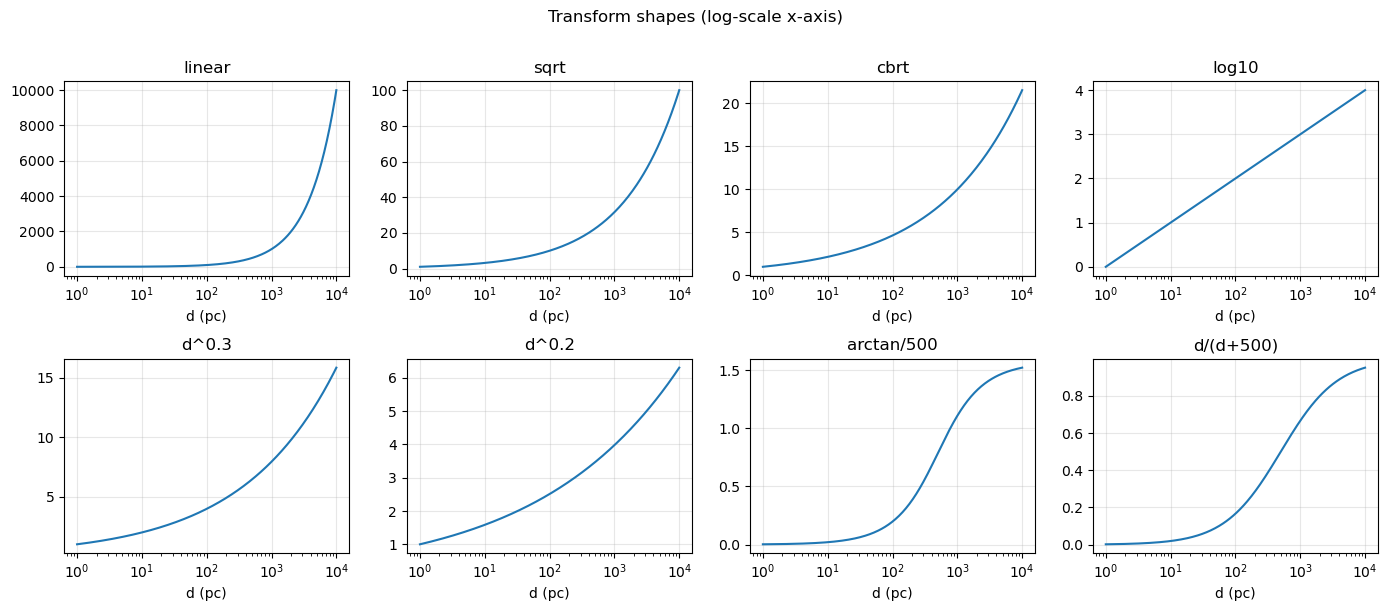

In [5]:
# background distance used for no-parallax group (in raw parsecs, transformed alongside)
BG_DIST_PC = 5000.0

transforms = {
    "linear":       lambda d: d,
    "sqrt":         lambda d: np.sqrt(d),
    "cbrt":         lambda d: np.cbrt(d),
    "log10":        lambda d: np.log10(d),
    "d^0.3":        lambda d: d ** 0.3,
    "d^0.2":        lambda d: d ** 0.2,
    "arctan/500":   lambda d: np.arctan(d / 500),
    "d/(d+500)":    lambda d: d / (d + 500),
}

# preview transform shapes
d_test = np.logspace(0, 4, 300)   # 1 → 10 000 pc

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (name, fn) in zip(axes.flat, transforms.items()):
    ax.plot(d_test, fn(d_test))
    ax.set_title(name)
    ax.set_xlabel("d (pc)")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
plt.suptitle("Transform shapes (log-scale x-axis)", y=1.01)
plt.tight_layout()
plt.show()

## 5. 3D scatter — all transforms at once

Rotate the figure to compare depth distribution.

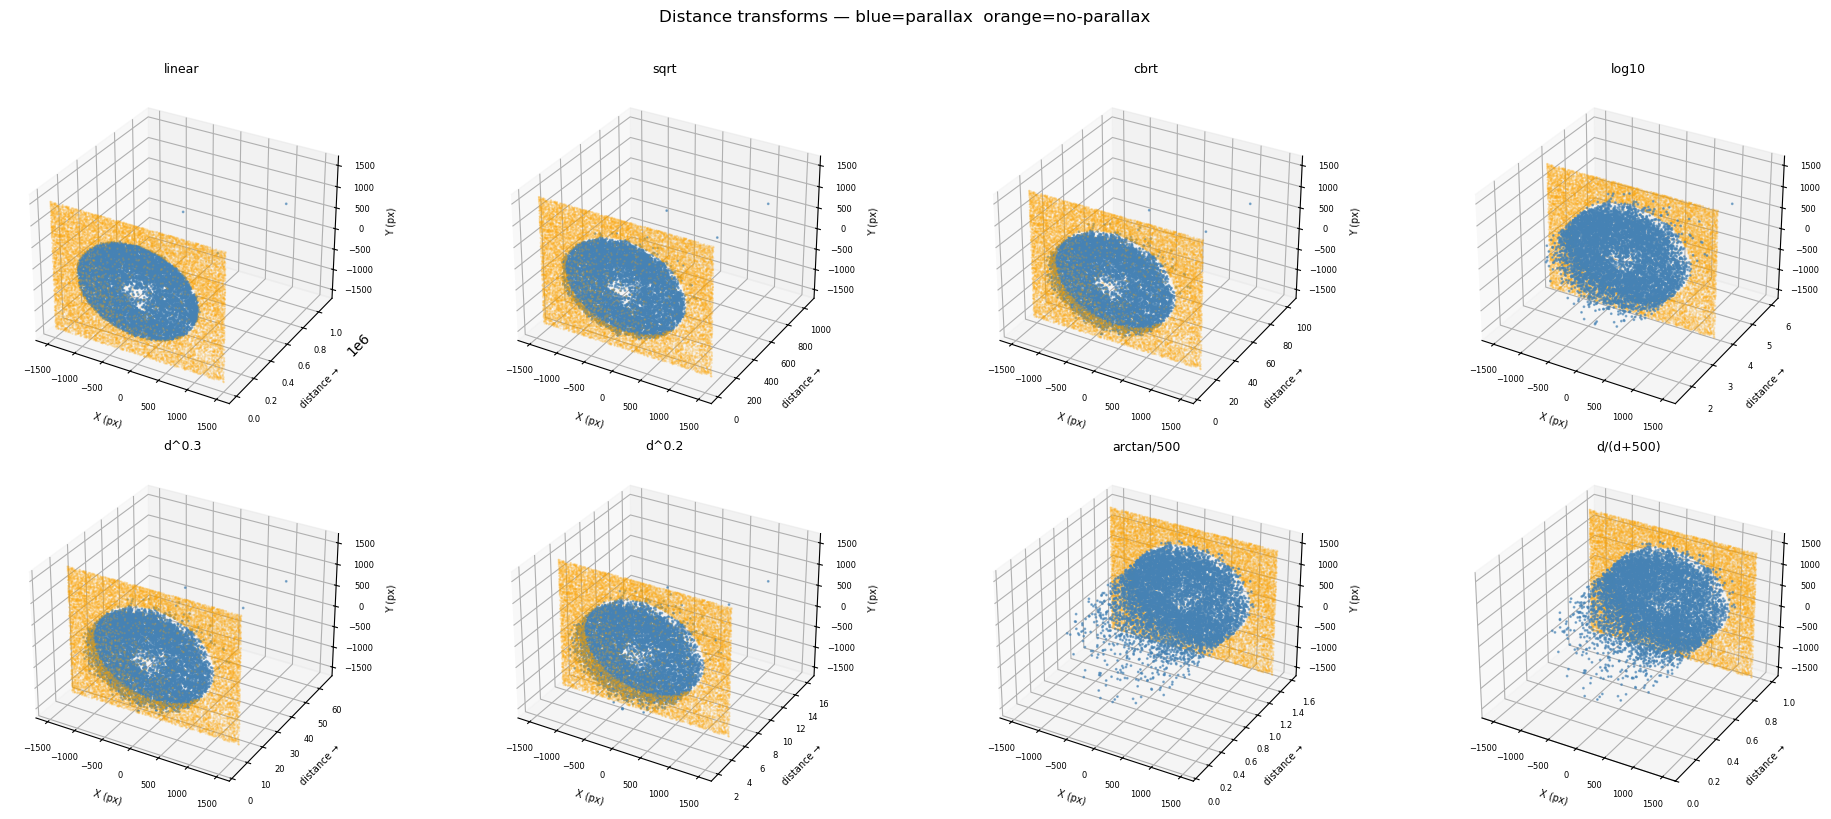

In [6]:
%matplotlib inline

n_transforms = len(transforms)
ncols = 4
nrows = int(np.ceil(n_transforms / ncols))

fig = plt.figure(figsize=(5 * ncols, 4 * nrows))

for i, (name, fn) in enumerate(transforms.items()):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")

    sx, sy, sz = to_scene(p["x"].values, p["y"].values, fn(p["dist_pc"].values))
    ax.scatter(sx, sy, sz, s=1, c="steelblue", alpha=0.6)

    bx, by, bz = to_scene(npd["x"].values, npd["y"].values,
                           np.full(len(npd), fn(BG_DIST_PC)))
    ax.scatter(bx, by, bz, s=0.3, c="orange", alpha=0.2)

    ax.set_title(name, fontsize=9)
    ax.set_xlabel("X (px)", fontsize=7)
    ax.set_ylabel("distance →", fontsize=7)
    ax.set_zlabel("Y (px)", fontsize=7)
    ax.tick_params(labelsize=6)

plt.suptitle("Distance transforms — blue=parallax  orange=no-parallax", y=1.01)
plt.tight_layout()
plt.show()

## 6. Single transform — large interactive plot

Pick your favourite from above and inspect it closely.

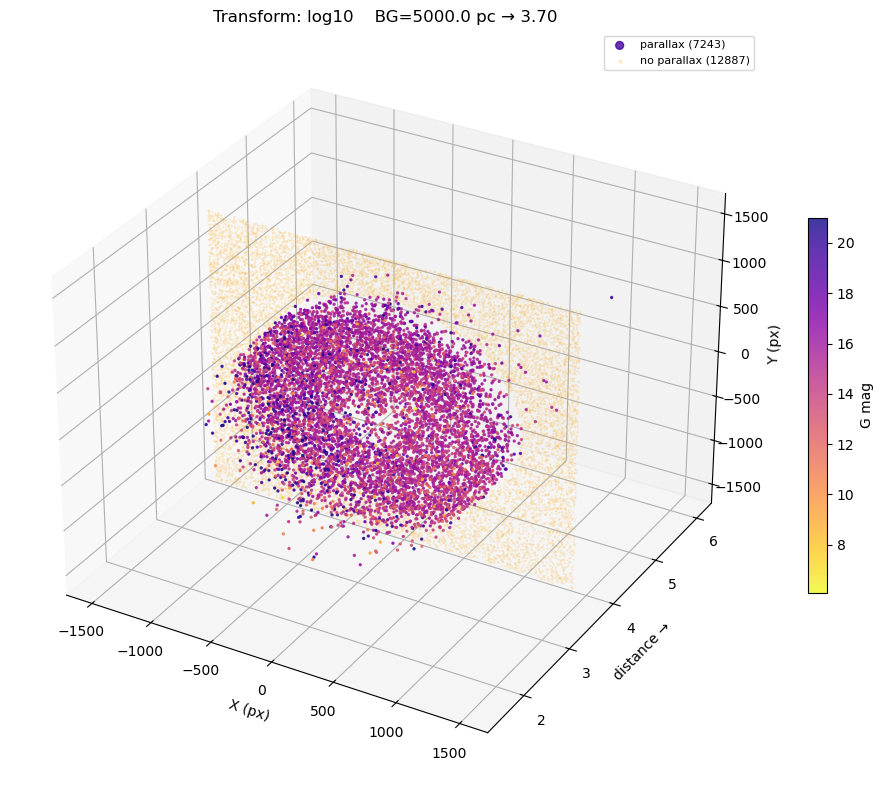

In [13]:
CHOSEN = "log10"      # ← change this
%matplotlib notebook
%matplotlib inline
fn = transforms[CHOSEN]

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")

sx, sy, sz = to_scene(p["x"].values, p["y"].values, fn(p["dist_pc"].values))
sc = ax.scatter(sx, sy, sz,
                s=2,
                c=p["gaia_g_mag"].values,
                cmap="plasma_r",
                alpha=0.8,
                label=f"parallax ({len(p)})")
plt.colorbar(sc, ax=ax, shrink=0.5, label="G mag")

bx, by, bz = to_scene(npd["x"].values, npd["y"].values,
                       np.full(len(npd), fn(BG_DIST_PC)))
ax.scatter(bx, by, bz, s=0.3, c="orange", alpha=0.15, label=f"no parallax ({len(npd)})")

ax.set_title(f"Transform: {CHOSEN}    BG={BG_DIST_PC} pc → {fn(BG_DIST_PC):.2f}")
ax.set_xlabel("X (px)")
ax.set_ylabel("distance →")
ax.set_zlabel("Y (px)")
ax.legend(markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Distance histogram — before and after transform

Useful for checking how many stars fall at each depth.

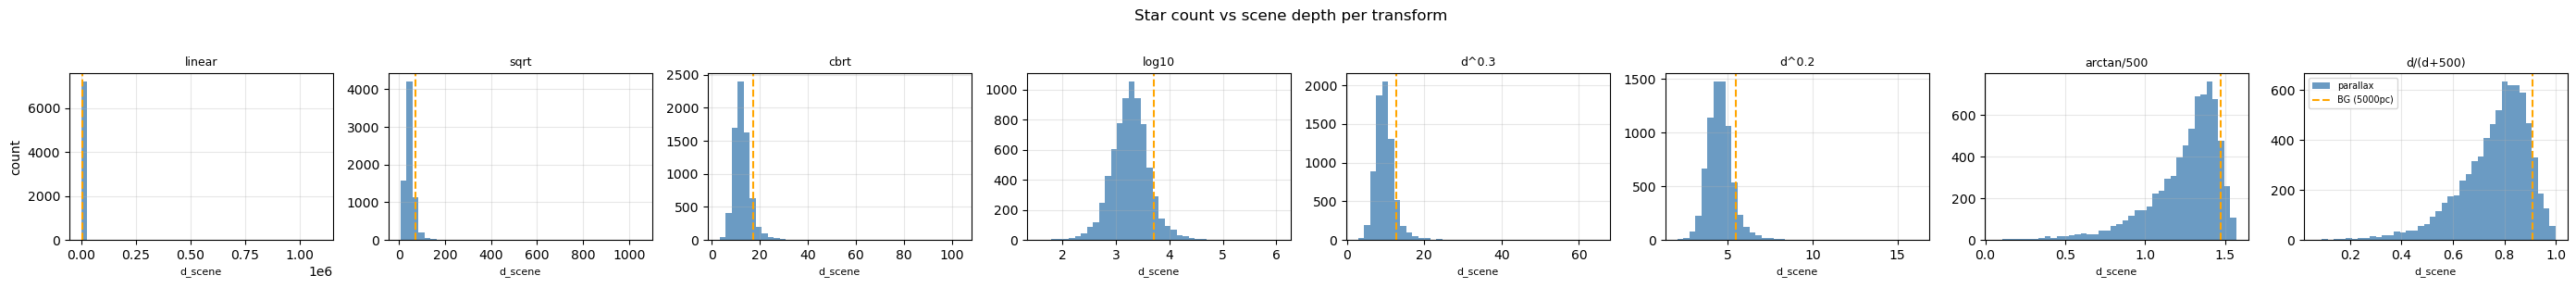

In [19]:
%matplotlib inline

d_raw = p["dist_pc"].values

fig, axes = plt.subplots(1, len(transforms), figsize=(3.5 * len(transforms), 3))
for ax, (name, fn) in zip(axes, transforms.items()):
    ax.hist(fn(d_raw), bins=40, color="steelblue", alpha=0.8, label="parallax")
    ax.axvline(fn(BG_DIST_PC), color="orange", linewidth=1.5,
               linestyle="--", label=f"BG ({BG_DIST_PC:.0f}pc)")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("d_scene", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("count")
axes[-1].legend(fontsize=7)
plt.suptitle("Star count vs scene depth per transform", y=1.02)
plt.tight_layout()
plt.show()